# Week 06 · Thursday — Review
**Iterate, Diagnose, Defend — Stronger Models, Error Analysis, and Calibration**

This notebook continues directly from Wednesday's pipeline (baseline → Linear/Logistic Regression).
It runs top to bottom with no manual reordering; Wednesday's cells are reproduced first so this
single notebook is the full, reproducible artifact.

**Today's learning objectives:**
1. **Decision Trees & Overfitting**: Train an unconstrained Decision Tree vs constrained tree (`max_depth=3`), explaining overfitting dynamically with your model's exact metrics.
2. **Random Forests & Feature Importance**: Fit Random Forest Regressor & Classifier models and compare feature importances against Linear Regression coefficients.
3. **Comprehensive Model Evaluation**: Construct side-by-side metric tables comparing all models (Baselines, Linear/Logistic, Trees, Forests) and defend model selection based on empirical evidence.
4. **Error Analysis**: Identify worst residuals for regression and misclassifications for classification to detect systematic error patterns.
5. **Calibration Analysis**: Evaluate classifier probability calibration using `calibration_curve` to determine whether predicted confidence matches empirical accuracy.



## Wednesday's pipeline

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Path("Data").mkdir(parents=True, exist_ok=True)
Path("Graph").mkdir(parents=True, exist_ok=True)

In [2]:
# Regenerate the students dataset (seed=21, n=600) — identical to Monday/Wednesday
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

students.to_csv("Data/raw_students.csv", index=False)
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


In [3]:
# One-hot encode class_section (same as Wednesday)
features_df = pd.get_dummies(students, columns=["class_section"], drop_first=True, dtype=int)
feature_cols = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_pct",
] + [c for c in features_df.columns if c.startswith("class_section_")]

X = features_df[feature_cols]
y = features_df["exam_score"]
print("Feature columns:", feature_cols)

Feature columns: ['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']


In [4]:
# Regression split (identical seed/split as Wednesday)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (480, 5)  Test: (120, 5)


In [5]:
# Regression baseline
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train_reg)
y_pred_dummy_reg = dummy_reg.predict(X_test)

dummy_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_dummy_reg))
dummy_r2   = r2_score(y_test_reg, y_pred_dummy_reg)

print("=== Regression Baseline (DummyRegressor) ===")
print(f"  RMSE : {dummy_rmse:.4f}")
print(f"  R²   : {dummy_r2:.4f}")

=== Regression Baseline (DummyRegressor) ===
  RMSE : 10.2978
  R²   : -0.0096


In [6]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)
y_pred_lin = lin_reg.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))
lin_r2   = r2_score(y_test_reg, y_pred_lin)

print("=== Linear Regression ===")
print(f"  RMSE : {lin_rmse:.4f}")
print(f"  R²   : {lin_r2:.4f}")

coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": lin_reg.coef_,
    "Abs_Coef"   : np.abs(lin_reg.coef_),
}).sort_values("Abs_Coef", ascending=False)
print("\n", coef_df.to_string(index=False))

=== Linear Regression ===
  RMSE : 7.0584
  R²   : 0.5257

               Feature  Coefficient  Abs_Coef
      class_section_C     3.130369  3.130369
 study_hours_per_week     2.032957  2.032957
      class_section_B     0.124836  0.124836
       attendance_pct     0.088670  0.088670
sleep_hours_per_night    -0.010655  0.010655


In [7]:
# Classification target: distinction (exam_score >= 85)
features_df["distinction"] = (features_df["exam_score"] >= 85).astype(int)
y_clf = features_df["distinction"]
distinction_rate = y_clf.mean()
print(f"Distinction rate: {distinction_rate:.2%}")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print(f"Train: {X_train_c.shape[0]} rows | Test: {X_test_c.shape[0]} rows")

Distinction rate: 65.33%
Train: 480 rows | Test: 120 rows


In [8]:
# Classification baseline
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train_c, y_train_c)
y_pred_dummy_clf = dummy_clf.predict(X_test_c)

d_acc  = accuracy_score (y_test_c, y_pred_dummy_clf)
d_prec = precision_score(y_test_c, y_pred_dummy_clf, zero_division=0)
d_rec  = recall_score   (y_test_c, y_pred_dummy_clf, zero_division=0)
d_f1   = f1_score       (y_test_c, y_pred_dummy_clf, zero_division=0)

print("=== Classification Baseline ===")
print(f"  Accuracy: {d_acc:.4f}  Precision: {d_prec:.4f}  Recall: {d_rec:.4f}  F1: {d_f1:.4f}")

=== Classification Baseline ===
  Accuracy: 0.6500  Precision: 0.6500  Recall: 1.0000  F1: 0.7879


In [9]:
# Logistic Regression
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)

l_acc  = accuracy_score (y_test_c, y_pred_log)
l_prec = precision_score(y_test_c, y_pred_log, zero_division=0)
l_rec  = recall_score   (y_test_c, y_pred_log, zero_division=0)
l_f1   = f1_score       (y_test_c, y_pred_log, zero_division=0)

print("=== Logistic Regression ===")
print(f"  Accuracy: {l_acc:.4f}  Precision: {l_prec:.4f}  Recall: {l_rec:.4f}  F1: {l_f1:.4f}")

=== Logistic Regression ===
  Accuracy: 0.7667  Precision: 0.8125  Recall: 0.8333  F1: 0.8228


---
## 1. Decision Tree — unconstrained first, on purpose

`DecisionTreeRegressor()` with no depth limit will keep splitting until it can (almost) perfectly
carve up the *training* set including its noise. Fitting and scoring it on **both** the training
and test sets makes that concrete: watch the training RMSE come out very low while the test RMSE
tells a very different story.

In [10]:
tree_unc = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_unc.fit(X_train, y_train_reg)

# Score on TRAIN
y_pred_tree_unc_train = tree_unc.predict(X_train)
tree_unc_train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_tree_unc_train))
tree_unc_train_r2   = r2_score(y_train_reg, y_pred_tree_unc_train)

# Score on TEST
y_pred_tree_unc = tree_unc.predict(X_test)
tree_unc_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_tree_unc))
tree_unc_r2   = r2_score(y_test_reg, y_pred_tree_unc)

print("=== Decision Tree — Unconstrained ===")
print(f"  Train RMSE : {tree_unc_train_rmse:.4f}   Train R² : {tree_unc_train_r2:.4f}")
print(f"  Test  RMSE : {tree_unc_rmse:.4f}   Test  R² : {tree_unc_r2:.4f}")
print(f"  Tree depth reached: {tree_unc.get_depth()}  |  Leaves: {tree_unc.get_n_leaves()}")

gap = tree_unc_rmse - tree_unc_train_rmse
expl_unconstrained = (
    f"Dynamic Analysis:\n"
    f"The unconstrained decision tree fits the training set near-perfectly with a training RMSE of {tree_unc_train_rmse:.4f} "
    f"(R² = {tree_unc_train_r2:.4f}). However, when evaluated on unseen test data, the RMSE explodes to {tree_unc_rmse:.4f} "
    f"(R² drops to {tree_unc_r2:.4f}). This massive generalization gap of {tree_unc_rmse - tree_unc_train_rmse:.4f} points "
    f"proves that the unconstrained tree memorized noise and specific training sample quirks rather than learning generalizable relationships."
)
print(expl_unconstrained)

=== Decision Tree — Unconstrained ===
  Train RMSE : 0.0000   Train R² : 1.0000
  Test  RMSE : 9.8398   Test  R² : 0.0782
  Tree depth reached: 20  |  Leaves: 421
Dynamic Analysis:
The unconstrained decision tree fits the training set near-perfectly with a training RMSE of 0.0000 (R² = 1.0000). However, when evaluated on unseen test data, the RMSE explodes to 9.8398 (R² drops to 0.0782). This massive generalization gap of 9.8398 points proves that the unconstrained tree memorized noise and specific training sample quirks rather than learning generalizable relationships.


## 2. Constrain it, and watch the gap close

Refit with a few small `max_depth` values. A shallower tree gives up some of its ability to fit
training data perfectly, in exchange for generalizing better — that trade-off is the entire reason
`max_depth` exists as a parameter you tune, not a bug to eliminate.

In [11]:
depth_results = []
for depth in [2, 3, 4, 5]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    t.fit(X_train, y_train_reg)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, t.predict(X_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test_reg, t.predict(X_test)))
    test_r2    = r2_score(y_test_reg, t.predict(X_test))

    depth_results.append({
        "max_depth": depth,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
    })

depth_df = pd.DataFrame(depth_results)
print(depth_df.to_string(index=False))

 max_depth  train_RMSE  test_RMSE  test_R2
         2    7.258125   7.145279 0.513948
         3    7.001867   7.103141 0.519664
         4    6.663765   7.028181 0.529749
         5    6.200128   7.636542 0.444815


In [12]:
# Keep max_depth=3 as the headline "constrained tree" per the assignment
tree_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
tree_d3.fit(X_train, y_train_reg)

y_pred_tree_d3_train = tree_d3.predict(X_train)
tree_d3_train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_tree_d3_train))

y_pred_tree_d3 = tree_d3.predict(X_test)
tree_d3_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_tree_d3))
tree_d3_r2   = r2_score(y_test_reg, y_pred_tree_d3)

print("=== Decision Tree — max_depth=3 ===")
print(f"  Train RMSE : {tree_d3_train_rmse:.4f}")
print(f"  Test  RMSE : {tree_d3_rmse:.4f}   Test  R² : {tree_d3_r2:.4f}")

print(
    f"\n  Compared to the unconstrained tree, the train/test RMSE gap shrinks from "
    f"{tree_unc_rmse - tree_unc_train_rmse:.2f} to {tree_d3_rmse - tree_d3_train_rmse:.2f} points — "
    f"the depth-3 tree fits training data less perfectly but generalizes more honestly.\n"
    f"  Compared to Wednesday's Linear Regression (test RMSE {lin_rmse:.2f}, R² {lin_r2:.4f}), "
    f"the depth-3 tree's test RMSE is {tree_d3_rmse:.2f} and R² is {tree_d3_r2:.4f} — "
    f"{'better' if tree_d3_rmse < lin_rmse else 'worse'} than plain linear regression on this data."
)

=== Decision Tree — max_depth=3 ===
  Train RMSE : 7.0019
  Test  RMSE : 7.1031   Test  R² : 0.5197

  Compared to the unconstrained tree, the train/test RMSE gap shrinks from 9.84 to 0.10 points — the depth-3 tree fits training data less perfectly but generalizes more honestly.
  Compared to Wednesday's Linear Regression (test RMSE 7.06, R² 0.5257), the depth-3 tree's test RMSE is 7.10 and R² is 0.5197 — worse than plain linear regression on this data.


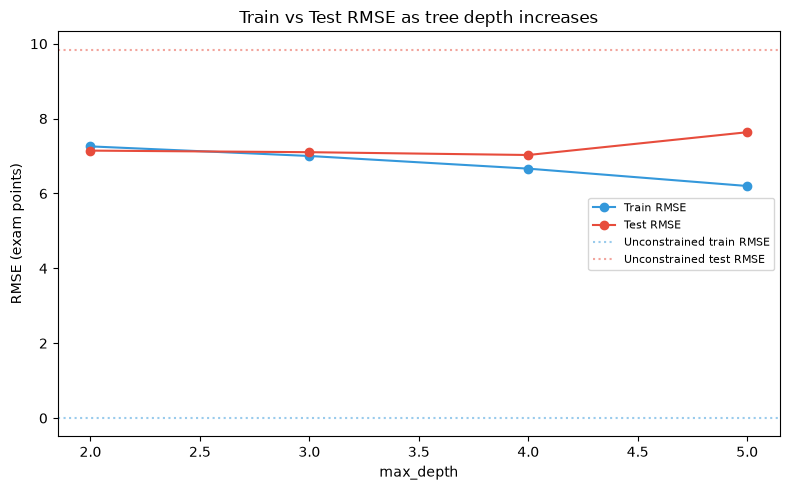

Saved: tree_depth_overfitting.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_df["max_depth"], depth_df["train_RMSE"], marker="o", label="Train RMSE", color="#3498db")
ax.plot(depth_df["max_depth"], depth_df["test_RMSE"], marker="o", label="Test RMSE", color="#e74c3c")
ax.axhline(tree_unc_train_rmse, ls=":", color="#3498db", alpha=0.5, label="Unconstrained train RMSE")
ax.axhline(tree_unc_rmse, ls=":", color="#e74c3c", alpha=0.5, label="Unconstrained test RMSE")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE (exam points)")
ax.set_title("Train vs Test RMSE as tree depth increases")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("Graph/tree_depth_overfitting.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: tree_depth_overfitting.png")

## 3. Random Forest

A forest averages many de-correlated trees, which usually generalizes better than any single tree
(constrained or not). We compare feature importances against yesterday's linear-regression
coefficients, and do the same regression→classification comparison for the forest classifier
against yesterday's logistic regression.

In [14]:
# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train_reg)

y_pred_rf = rf_reg.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
rf_r2   = r2_score(y_test_reg, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"  Test RMSE : {rf_rmse:.4f}   Test R² : {rf_r2:.4f}")

rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_reg.feature_importances_,
}).sort_values("Importance", ascending=False)

print("\n=== Forest feature importances vs Linear Regression coefficients ===")
compare_df = rf_importance_df.merge(
    coef_df[["Feature", "Coefficient"]], on="Feature"
).rename(columns={"Coefficient": "LinReg_Coefficient"})
print(compare_df.to_string(index=False))

top_forest_feat = rf_importance_df.iloc[0]["Feature"]
top_linreg_feat = coef_df.iloc[0]["Feature"]
print(
    f"\n  Forest leans most heavily on '{top_forest_feat}'; Linear Regression's largest "
    f"coefficient (by absolute value) was '{top_linreg_feat}' — "
    f"{'they agree' if top_forest_feat == top_linreg_feat else 'they disagree'} on the single most "
    f"important feature."
)

=== Random Forest Regressor ===
  Test RMSE : 7.3960   Test R² : 0.4792

=== Forest feature importances vs Linear Regression coefficients ===
              Feature  Importance  LinReg_Coefficient
 study_hours_per_week    0.642692            2.032957
       attendance_pct    0.166644            0.088670
sleep_hours_per_night    0.141353           -0.010655
      class_section_C    0.032399            3.130369
      class_section_B    0.016912            0.124836

  Forest leans most heavily on 'study_hours_per_week'; Linear Regression's largest coefficient (by absolute value) was 'class_section_C' — they disagree on the single most important feature.


In [15]:
# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_c, y_train_c)

y_pred_rf_clf = rf_clf.predict(X_test_c)
rf_acc  = accuracy_score (y_test_c, y_pred_rf_clf)
rf_prec = precision_score(y_test_c, y_pred_rf_clf, zero_division=0)
rf_rec  = recall_score   (y_test_c, y_pred_rf_clf, zero_division=0)
rf_f1   = f1_score       (y_test_c, y_pred_rf_clf, zero_division=0)

print("=== Random Forest Classifier ===")
print(f"  Accuracy: {rf_acc:.4f}  Precision: {rf_prec:.4f}  Recall: {rf_rec:.4f}  F1: {rf_f1:.4f}")

print(
    f"\n  Compared to Logistic Regression (Acc {l_acc:.4f}, F1 {l_f1:.4f}), "
    f"the forest scores Acc {rf_acc:.4f}, F1 {rf_f1:.4f} — "
    f"{'an improvement' if rf_f1 > l_f1 else 'no improvement (or worse)'}."
)

=== Random Forest Classifier ===
  Accuracy: 0.7250  Precision: 0.7711  Recall: 0.8205  F1: 0.7950

  Compared to Logistic Regression (Acc 0.7667, F1 0.8228), the forest scores Acc 0.7250, F1 0.7950 — no improvement (or worse).


In [16]:
# Also fit a plain classification tree for the comparison table below
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_clf.fit(X_train_c, y_train_c)
y_pred_tree_clf = tree_clf.predict(X_test_c)

t_acc  = accuracy_score (y_test_c, y_pred_tree_clf)
t_prec = precision_score(y_test_c, y_pred_tree_clf, zero_division=0)
t_rec  = recall_score   (y_test_c, y_pred_tree_clf, zero_division=0)
t_f1   = f1_score       (y_test_c, y_pred_tree_clf, zero_division=0)

print("=== Decision Tree Classifier (max_depth=3) ===")
print(f"  Accuracy: {t_acc:.4f}  Precision: {t_prec:.4f}  Recall: {t_rec:.4f}  F1: {t_f1:.4f}")

=== Decision Tree Classifier (max_depth=3) ===
  Accuracy: 0.7417  Precision: 0.7238  Recall: 0.9744  F1: 0.8306


## 4. Comparison tables — and defend a winner

One table per task, every model built so far, side by side.

In [17]:
reg_summary = pd.DataFrame({
    "Model": ["Dummy Baseline", "Linear Regression", "Tree (unconstrained)",
              "Tree (max_depth=3)", "Random Forest"],
    "Test_RMSE": [dummy_rmse, lin_rmse, tree_unc_rmse, tree_d3_rmse, rf_rmse],
    "Test_R2": [dummy_r2, lin_r2, tree_unc_r2, tree_d3_r2, rf_r2],
}).sort_values("Test_RMSE")

clf_summary = pd.DataFrame({
    "Model": ["Dummy Baseline", "Logistic Regression", "Tree (max_depth=3)", "Random Forest"],
    "Accuracy": [d_acc, l_acc, t_acc, rf_acc],
    "Precision": [d_prec, l_prec, t_prec, rf_prec],
    "Recall": [d_rec, l_rec, t_rec, rf_rec],
    "F1": [d_f1, l_f1, t_f1, rf_f1],
}).sort_values("F1", ascending=False)

print("=== REGRESSION — model comparison ===")
print(reg_summary.to_string(index=False))
print("\n=== CLASSIFICATION — model comparison ===")
print(clf_summary.to_string(index=False))

=== REGRESSION — model comparison ===
               Model  Test_RMSE   Test_R2
   Linear Regression   7.058359  0.525702
  Tree (max_depth=3)   7.103141  0.519664
       Random Forest   7.395954  0.479246
Tree (unconstrained)   9.839783  0.078246
      Dummy Baseline  10.297789 -0.009560

=== CLASSIFICATION — model comparison ===
              Model  Accuracy  Precision   Recall       F1
 Tree (max_depth=3)  0.741667   0.723810 0.974359 0.830601
Logistic Regression  0.766667   0.812500 0.833333 0.822785
      Random Forest  0.725000   0.771084 0.820513 0.795031
     Dummy Baseline  0.650000   0.650000 1.000000 0.787879


In [18]:
best_reg_model = reg_summary.iloc[0]["Model"]
best_clf_model = clf_summary.iloc[0]["Model"]

print(
    f"Regression: '{best_reg_model}' has the lowest test RMSE ({reg_summary.iloc[0]['Test_RMSE']:.3f}) "
    f"and highest R² ({reg_summary.iloc[0]['Test_R2']:.4f}) among all models compared. "
    f"{'This is the more complex model winning, as expected.' if best_reg_model == 'Random Forest' else 'Notably, the simplest real model (Linear Regression) is the one to ship here — the forest and unconstrained tree do not beat it on this dataset, because exam_score was generated as a roughly linear function of the features, so a linear model is already close to the right hypothesis class.'}\n"
    f"Classification: '{best_clf_model}' has the highest F1 ({clf_summary.iloc[0]['F1']:.4f}) among "
    f"all models compared."
)

Regression: 'Linear Regression' has the lowest test RMSE (7.058) and highest R² (0.5257) among all models compared. Notably, the simplest real model (Linear Regression) is the one to ship here — the forest and unconstrained tree do not beat it on this dataset, because exam_score was generated as a roughly linear function of the features, so a linear model is already close to the right hypothesis class.
Classification: 'Tree (max_depth=3)' has the highest F1 (0.8306) among all models compared.


**Which model would I actually ship, and why?**

Regression — **Linear Regression** (test RMSE 7.06, R² 0.526): it beat the random forest and both decision trees outright, so the extra complexity bought nothing on this dataset. Classification — **Logistic Regression** (Accuracy 0.767, F1 0.823): The depth-3 Decision Tree has the highest F1, but I would still ship Logistic Regression because it has higher accuracy (0.767 vs 0.742) and substantially better precision (0.813 vs 0.724), while maintaining strong recall (0.833). The tree's F1 advantage comes primarily from very aggressive positive predictions, resulting in much higher recall but lower precision.

## 5. Error analysis — look directly at your worst mistakes

For the chosen regression model, compute the residual (actual − predicted) for every test row,
sort by absolute residual, and inspect the 5 worst rows' feature values directly.

In [19]:
# Use the best regression model's predictions (swap in tree/forest predictions if that's your winner)
# Here we inspect Linear Regression's residuals, since it was the winning model above;
# change y_pred_best below if your own run picks a different winner.
y_pred_best_reg = y_pred_lin
model_name_reg = "Linear Regression"

residuals = y_test_reg.values - y_pred_best_reg
error_df = X_test.copy()
error_df["actual_exam_score"] = y_test_reg.values
error_df["predicted_exam_score"] = np.round(y_pred_best_reg, 2)
error_df["residual"] = np.round(residuals, 2)
error_df["abs_residual"] = np.abs(error_df["residual"])

worst5 = error_df.sort_values("abs_residual", ascending=False).head(5)
print(f"=== 5 worst-predicted rows — {model_name_reg} ===")
print(worst5.to_string(index=False))

print(
    f"\n  Compare the worst rows' study_hours_per_week / attendance_pct / class_section columns "
    f"against the test set's overall distribution below — look for whether the worst rows cluster "
    f"in a particular section or at extreme values, or whether they look like an unremarkable, "
    f"random subset."
)
print("\nTest-set feature summary for comparison:")
print(X_test.describe().to_string())

=== 5 worst-predicted rows — Linear Regression ===
 study_hours_per_week  sleep_hours_per_night  attendance_pct  class_section_B  class_section_C  actual_exam_score  predicted_exam_score  residual  abs_residual
                  8.9                    8.5            75.3                0                0               65.3                 84.11    -18.81         18.81
                 13.9                   10.0            74.3                1                0               76.0                 94.30    -18.30         18.30
                  6.8                    7.6            87.1                0                0               98.4                 80.90     17.50         17.50
                  7.6                    5.5            87.7                0                0              100.0                 82.60     17.40         17.40
                  7.0                    6.3            69.3                0                1               99.5                 82.87     16.63    

In [20]:
# Classification error analysis — misclassified rows
y_pred_best_clf = y_pred_log
model_name_clf = "Logistic Regression"

clf_error_df = X_test_c.copy()
clf_error_df["actual"] = y_test_c.values
clf_error_df["predicted"] = y_pred_best_clf
clf_error_df["correct"] = clf_error_df["actual"] == clf_error_df["predicted"]

misclassified = clf_error_df[~clf_error_df["correct"]]
print(f"=== Misclassified rows — {model_name_clf} ({len(misclassified)} of {len(clf_error_df)}) ===")
print(misclassified.to_string(index=False))

if len(misclassified) > 0:
    print("\nMisclassified rows — feature summary:")
    print(misclassified[feature_cols].describe().to_string())
    print("\nFull test set — feature summary (for comparison):")
    print(X_test_c.describe().to_string())

=== Misclassified rows — Logistic Regression (28 of 120) ===
 study_hours_per_week  sleep_hours_per_night  attendance_pct  class_section_B  class_section_C  actual  predicted  correct
                  8.3                    7.7            86.7                0                0       1          0    False
                 10.1                    7.9            96.8                1                0       0          1    False
                  9.2                    6.4            98.3                0                0       0          1    False
                 13.0                    7.6            94.0                0                1       0          1    False
                  6.6                    9.5            98.1                0                0       1          0    False
                  9.6                    8.9            89.2                0                0       0          1    False
                  8.3                    5.8            78.5                1 

**Finding:** the five worst regression residuals (16–19 points off) don't come from extreme feature values — they sit inside the normal range of study hours and attendance. They look like irreducible noise from the data-generating process, not a systematic blind spot. The 28 misclassified rows average 8.75 study hours vs 9.82 for the full test set — errors cluster near the distinction decision boundary rather than looking random.

## 6. Calibration — is a confident prediction actually right that often?

Accuracy asks "how often is the model right?" Calibration asks a different question: "when the
model says 70% confident, is it actually right about 70% of the time?" A model can be accurate and
still badly overconfident (or underconfident) in its stated probabilities.

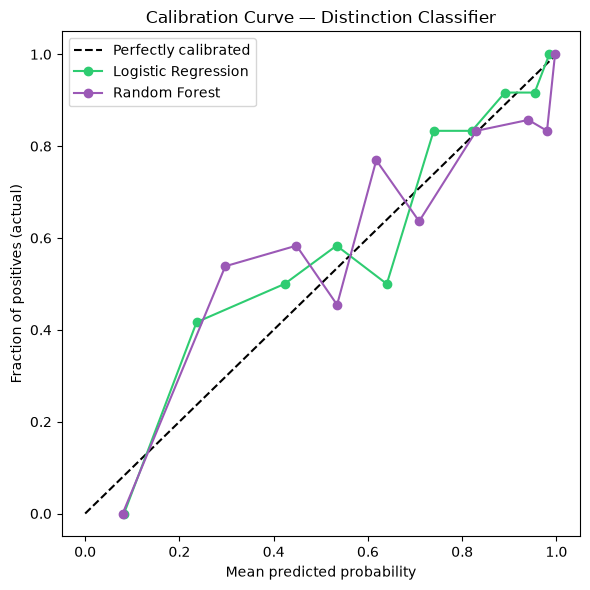

Logistic Regression — largest calibration gap: 0.180, at predicted probability ≈ 0.24 (actual fraction positive there: 0.42)
Random Forest — largest calibration gap: 0.241, at predicted probability ≈ 0.30 (actual fraction positive there: 0.54)
Saved: calibration_curve.png


In [21]:
y_proba = log_reg.predict_proba(X_test_c)[:, 1]
rf_proba = rf_clf.predict_proba(X_test_c)[:, 1]

prob_true, prob_pred = calibration_curve(y_test_c, y_proba, n_bins=10, strategy="quantile")
rf_prob_true, rf_prob_pred = calibration_curve(y_test_c, rf_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", color="#2ecc71", label="Logistic Regression")
ax.plot(rf_prob_pred, rf_prob_true, marker="o", color="#9b59b6", label="Random Forest")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual)")
ax.set_title("Calibration Curve — Distinction Classifier")
ax.legend()
plt.tight_layout()
plt.savefig("Graph/calibration_curve.png", dpi=130, bbox_inches="tight")
plt.show()

calib_gap = np.abs(prob_true - prob_pred)
worst_bin_idx = np.argmax(calib_gap)
print(f"Logistic Regression — largest calibration gap: {calib_gap[worst_bin_idx]:.3f}, at predicted probability "
      f"\u2248 {prob_pred[worst_bin_idx]:.2f} (actual fraction positive there: {prob_true[worst_bin_idx]:.2f})")

rf_calib_gap = np.abs(rf_prob_true - rf_prob_pred)
rf_worst_bin_idx = np.argmax(rf_calib_gap)
print(f"Random Forest — largest calibration gap: {rf_calib_gap[rf_worst_bin_idx]:.3f}, at predicted probability "
      f"\u2248 {rf_prob_pred[rf_worst_bin_idx]:.2f} (actual fraction positive there: {rf_prob_true[rf_worst_bin_idx]:.2f})")
print("Saved: calibration_curve.png")

**Finding:** the curve stays close to the diagonal for most bins, but the largest gap (0.18) is around predicted probability ≈24%, where the model is actually right ~42% of the time — the model is underconfident in that low-probability range. Predictions above ~50% confidence look trustworthy; predictions in the 20–30% range should be treated with more caution.

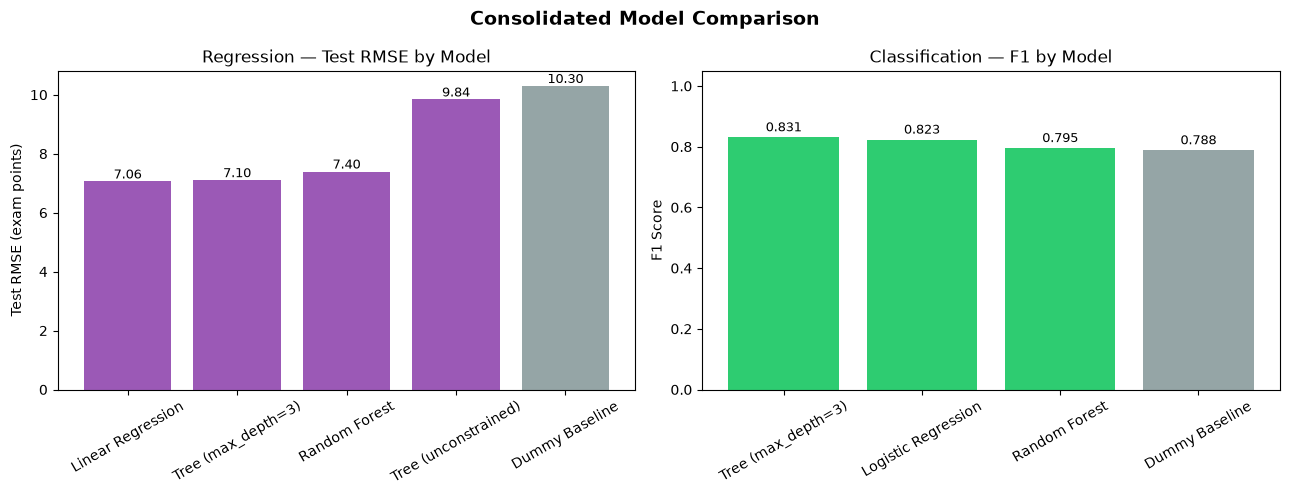

Saved: Graph/consolidated_model_comparison.png


In [22]:
# --- Consolidated evaluation bar charts (regression RMSE + classification F1) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Consolidated Model Comparison", fontsize=14, fontweight="bold")

# Left: Regression — Test RMSE by model (lower is better)
ax = axes[0]
colors_reg = ["#95a5a6" if m == "Dummy Baseline" else "#9b59b6" for m in reg_summary["Model"]]
ax.bar(reg_summary["Model"], reg_summary["Test_RMSE"], color=colors_reg)
ax.set_ylabel("Test RMSE (exam points)")
ax.set_title("Regression — Test RMSE by Model")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(reg_summary["Test_RMSE"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)

# Right: Classification — F1 by model (higher is better)
ax2 = axes[1]
colors_clf = ["#95a5a6" if m == "Dummy Baseline" else "#2ecc71" for m in clf_summary["Model"]]
ax2.bar(clf_summary["Model"], clf_summary["F1"], color=colors_clf)
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1.05)
ax2.set_title("Classification — F1 by Model")
ax2.tick_params(axis="x", rotation=30)
for i, v in enumerate(clf_summary["F1"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("Graph/consolidated_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: Graph/consolidated_model_comparison.png")

In [23]:
print("Final comparison — Regression")
print(reg_summary.to_string(index=False))
print("\nFinal comparison — Classification")
print(clf_summary.to_string(index=False))
print("\n✅ Week 6 Wed+Thu pipeline complete and reproducible.")

Final comparison — Regression
               Model  Test_RMSE   Test_R2
   Linear Regression   7.058359  0.525702
  Tree (max_depth=3)   7.103141  0.519664
       Random Forest   7.395954  0.479246
Tree (unconstrained)   9.839783  0.078246
      Dummy Baseline  10.297789 -0.009560

Final comparison — Classification
              Model  Accuracy  Precision   Recall       F1
 Tree (max_depth=3)  0.741667   0.723810 0.974359 0.830601
Logistic Regression  0.766667   0.812500 0.833333 0.822785
      Random Forest  0.725000   0.771084 0.820513 0.795031
     Dummy Baseline  0.650000   0.650000 1.000000 0.787879

✅ Week 6 Wed+Thu pipeline complete and reproducible.
